In [2]:
import torch
import torch.nn as nn
import torchaudio.transforms as T
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Dataset
from torchvision.models import convnext_tiny
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

directory = "C:/Users/lrozier/Documents/UQAC/respiratory-disease-detection/data/processed/"

# Configuration RTX 4070 : Tensor Cores (TF32)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Propulsé par : {torch.cuda.get_device_name(0)}")

X_features = np.load(directory + "X_features.npy")

Propulsé par : NVIDIA GeForce RTX 4070 SUPER


In [3]:
class GPUAugmenter(nn.Module):
    def __init__(self, sr=22050):
        super().__init__()
        self.mel_spec = T.MelSpectrogram(sample_rate=sr, n_fft=1024, hop_length=512, n_mels=128)
        self.amplitude_to_db = T.AmplitudeToDB(stype='power', top_db=80.0)
        self.freq_mask = T.FrequencyMasking(freq_mask_param=15)
        self.time_mask = T.TimeMasking(time_mask_param=35)
        self.pitch_shift = T.PitchShift(sample_rate=sr, n_steps=2)

    def forward(self, x, augment=True):
        x = torch.nan_to_num(x)
        if augment:
            if torch.rand(1) < 0.3: x = x + 0.001 * torch.randn_like(x)
            if torch.rand(1) < 0.2: x = self.pitch_shift(x)
            
        spec = self.amplitude_to_db(self.mel_spec(x) + 1e-10)
        
        if augment:
            if torch.rand(1) < 0.4: spec = self.freq_mask(spec)
            if torch.rand(1) < 0.4: spec = self.time_mask(spec)

        # Standardisation de l'image pour ConvNeXt
        spec = (spec - spec.mean()) / (spec.std() + 1e-8)
        return spec

class MultiModalDataset(Dataset):
    def __init__(self, x_audio, x_feats, y_labels):
        self.x_audio = x_audio
        self.x_feats = x_feats
        self.y = y_labels
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        audio = torch.tensor(self.x_audio[idx], dtype=torch.float32).unsqueeze(0)
        feat = torch.tensor(self.x_feats[idx], dtype=torch.float32)
        label = torch.tensor(self.y[idx], dtype=torch.long)
        return audio, feat, label


In [4]:
# ATTENTION : Pour l'augmenter GPU, on charge les signaux BRUTS (X_raw ou équivalent)
try:
    X = np.load(directory + "X.npy")
    y = np.load(directory + "y.npy")
    print(f"Données chargées : X={X.shape}, y={y.shape}")
except:
    print("Erreur : Fichier X.npy non trouvé. Vérifie le nom de tes signaux bruts.")

# Encodage des labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split en train, validation et test
split1 = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(split1.split(X, y_encoded))

X_train, X_temp = X[train_idx], X[temp_idx]
X_features_train, X_features_temp = X_features[train_idx], X_features[temp_idx]
y_train, y_temp = y_encoded[train_idx], y_encoded[temp_idx]

split2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(split2.split(X_temp, y_temp))

X_val, X_test = X_temp[val_idx], X_temp[test_idx]
X_features_val, X_features_test = X_features_temp[val_idx], X_features_temp[test_idx]
y_val, y_test = y_temp[val_idx], y_temp[test_idx]
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

scaler = StandardScaler()

# On apprend les paramètres uniquement sur le TRAIN
X_features_train = scaler.fit_transform(X_features_train)

# On applique les MÊMES paramètres (moyenne/std du train) au reste
X_features_val = scaler.transform(X_features_val)
X_features_test = scaler.transform(X_features_test)

Données chargées : X=(1201, 132300), y=(1201,)
Train: (840, 132300), Val: (180, 132300), Test: (181, 132300)


In [5]:
augmenter = GPUAugmenter(sr=22050).to(device)

train_loader = DataLoader(MultiModalDataset(X_train, X_features_train, y_train), batch_size=64, shuffle=True, pin_memory=True)
val_loader = DataLoader(MultiModalDataset(X_val, X_features_val, y_val), batch_size=64, pin_memory=True)


class RespiratoryFusionModel(nn.Module):
    def __init__(self, num_classes=5, num_features=16):
        super().__init__()
        # Branche CNN (ConvNeXt Tiny)
        self.cnn = convnext_tiny(weights="DEFAULT")
        
        # Adaptation 1 canal
        old_conv = self.cnn.features[0][0]
        self.cnn.features[0][0] = nn.Conv2d(1, old_conv.out_channels, kernel_size=4, stride=4)
        with torch.no_grad():
            self.cnn.features[0][0].weight.data = old_conv.weight.data.mean(dim=1, keepdim=True)
        
        self.cnn.classifier = nn.Sequential(
            nn.Flatten(1) # Transforme (B, 768, 1, 1) en (B, 768)
        )

        # Branche MLP pour les features acoustiques
        self.mlp = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # Classifieur Final (Fusion)
        # 768 + 64 = 832
        self.final_classifier = nn.Sequential(
            nn.Linear(832, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, spec, feat):
        cnn_out = self.cnn(spec)   # Maintenant en (Batch, 768)
        mlp_out = self.mlp(feat)   # Déjà en (Batch, 64)
        
        # Concaténation : (Batch, 832)
        combined = torch.cat((cnn_out, mlp_out), dim=1)
        return self.final_classifier(combined)
    
criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler('cuda')

In [12]:
# Initialisation
model = RespiratoryFusionModel(num_classes=len(le.classes_), num_features=X_features.shape[1]).to(device)


best_acc = 0.0
history = {"train_loss": [], "val_acc": []}

phases = [
    {"name": "Warmup (Freeze)", "epochs": 10, "lr": 1e-3, "freeze": True},
    {"name": "Fine-Tuning (Unfreeze)", "epochs": 100, "lr": 5e-5, "freeze": False}
]

for p_info in phases:
    print(f"\n>>> DÉBUT PHASE : {p_info['name']}")
    
    # Gestion du Freeze/Unfreeze
    for param in model.cnn.parameters():
        param.requires_grad = not p_info['freeze']
    
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                                  lr=p_info['lr'], weight_decay=1e-4)

    for epoch in range(p_info['epochs']):
        model.train()
        total_loss = 0
        for audios, feats, labels in train_loader:
            audios, feats, labels = audios.to(device, non_blocking=True), feats.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda'):
                # Augmentation GPU !
                specs = augmenter(audios, augment=(not p_info['freeze']))
                outputs = model(specs, feats)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for audios, feats, labels in val_loader:
                audios, feats, labels = audios.to(device), feats.to(device), labels.to(device)
                with torch.amp.autocast('cuda'):
                    specs = augmenter(audios, augment=False)
                    outputs = model(specs, feats)
                correct += (outputs.argmax(1) == labels).sum().item()
                total += labels.size(0)
        
        acc = correct / total
        history["train_loss"].append(total_loss/len(train_loader))
        history["val_acc"].append(acc)
        
        print(f"Epoch {epoch+1}/{p_info['epochs']} | Loss: {total_loss/len(train_loader):.4f} | Val Acc: {acc:.2%}")
        
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "best_model_respiratory_fusion.pth")



>>> DÉBUT PHASE : Warmup (Freeze)
Epoch 1/10 | Loss: 1.4339 | Val Acc: 61.11%
Epoch 2/10 | Loss: 1.1604 | Val Acc: 63.33%
Epoch 3/10 | Loss: 1.0493 | Val Acc: 65.00%
Epoch 4/10 | Loss: 0.9526 | Val Acc: 63.89%
Epoch 5/10 | Loss: 0.9239 | Val Acc: 67.78%
Epoch 6/10 | Loss: 0.8848 | Val Acc: 69.44%
Epoch 7/10 | Loss: 0.8363 | Val Acc: 71.11%
Epoch 8/10 | Loss: 0.7986 | Val Acc: 72.78%
Epoch 9/10 | Loss: 0.8085 | Val Acc: 71.67%
Epoch 10/10 | Loss: 0.7747 | Val Acc: 72.78%

>>> DÉBUT PHASE : Fine-Tuning (Unfreeze)
Epoch 1/100 | Loss: 0.7992 | Val Acc: 70.56%
Epoch 2/100 | Loss: 0.7367 | Val Acc: 76.11%
Epoch 3/100 | Loss: 0.7095 | Val Acc: 77.78%
Epoch 4/100 | Loss: 0.6491 | Val Acc: 81.67%
Epoch 5/100 | Loss: 0.5349 | Val Acc: 80.00%
Epoch 6/100 | Loss: 0.5483 | Val Acc: 78.33%
Epoch 7/100 | Loss: 0.4892 | Val Acc: 82.22%
Epoch 8/100 | Loss: 0.4375 | Val Acc: 85.56%
Epoch 9/100 | Loss: 0.3554 | Val Acc: 82.22%
Epoch 10/100 | Loss: 0.3790 | Val Acc: 84.44%
Epoch 11/100 | Loss: 0.2921 | V

ÉVALUATION DU MODÈLE SUR LE JEU DE TEST

Accuracy globale:        0.9392
Macro F1-score:          0.9339  <- Métrique clé
Weighted F1-score:       0.9396

RAPPORT DE CLASSIFICATION PAR CLASSE

(Sensibilité = Recall = % de vrais positifs détectés par classe)
              precision    recall  f1-score   support

      asthma     0.9744    0.8837    0.9268        43
   bronchial     0.9333    0.9333    0.9333        15
        copd     0.9833    0.9672    0.9752        61
     healthy     0.9474    0.9000    0.9231        20
   pneumonia     0.8542    0.9762    0.9111        42

    accuracy                         0.9392       181
   macro avg     0.9385    0.9321    0.9339       181
weighted avg     0.9431    0.9392    0.9396       181



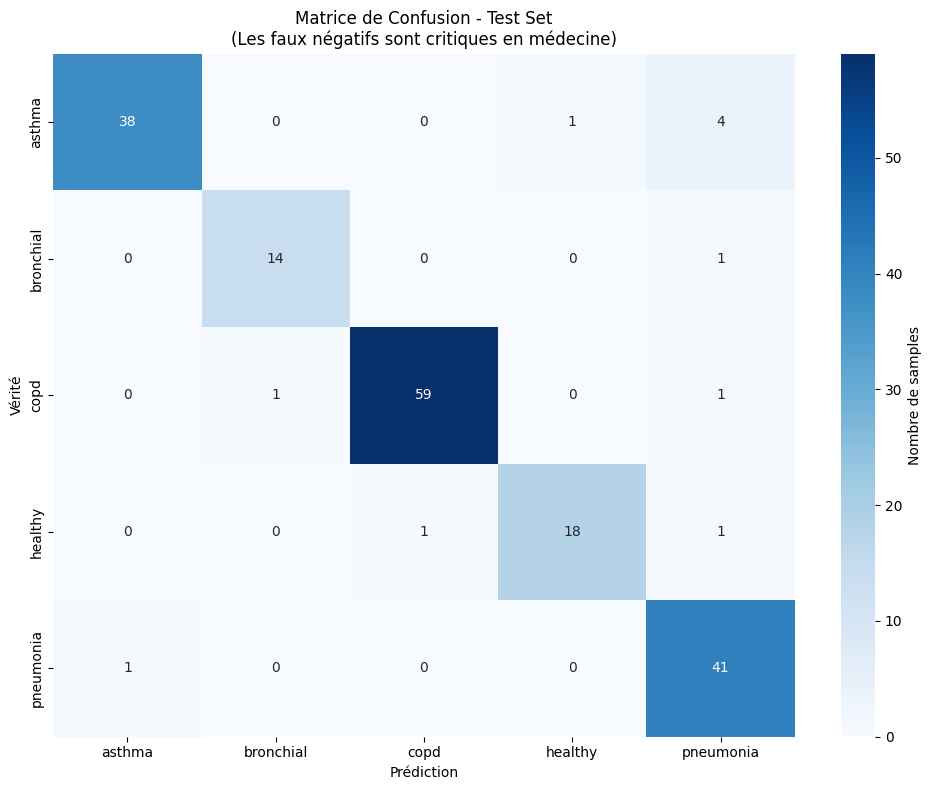


ANALYSE DES ERREURS - FAUX NÉGATIFS PAR CLASSE
asthma         : FN=  5, TP= 38, Sensibilité=0.8837
bronchial      : FN=  1, TP= 14, Sensibilité=0.9333
copd           : FN=  2, TP= 59, Sensibilité=0.9672
healthy        : FN=  2, TP= 18, Sensibilité=0.9000
pneumonia      : FN=  1, TP= 41, Sensibilité=0.9762

AUC-ROC PAR CLASSE
asthma         : AUC-ROC = 0.9911
bronchial      : AUC-ROC = 0.9996
copd           : AUC-ROC = 0.9989
healthy        : AUC-ROC = 0.9960
pneumonia      : AUC-ROC = 0.9824

Moyenne AUC-ROC: 0.9936


In [13]:
test_loader = DataLoader(MultiModalDataset(X_test, X_features_test, y_test), batch_size=64, shuffle=False, pin_memory=True)

model = RespiratoryFusionModel(num_classes=len(le.classes_), num_features=X_features.shape[1]).to(device)
model.load_state_dict(torch.load("../models/best_model_respiratory_fusion.pth"))

# Faire les prédictions sur le test set
model.eval()
y_test_pred = []
y_test_proba = []

with torch.no_grad():
    for audios, feats, labels in test_loader:
        # On envoie l'audio brut sur la 4070
        audios = audios.to(device, non_blocking=True)
        feats = feats.to(device, non_blocking=True)
        
        with torch.amp.autocast('cuda'):
            # Transformation en Spectrogramme sur GPU (sans augmentation)
            specs = augmenter(audios, augment=False)
            
            # Prédiction du modèle
            outputs = model(specs, feats)
            
        proba = torch.nn.functional.softmax(outputs, dim=1)
        y_test_pred.extend(outputs.argmax(dim=1).cpu().numpy())
        y_test_proba.extend(proba.cpu().numpy())

y_test_pred = np.array(y_test_pred)
y_test_proba = np.array(y_test_proba)

print("="*70)
print("ÉVALUATION DU MODÈLE SUR LE JEU DE TEST")
print("="*70)

accuracy = accuracy_score(y_test, y_test_pred)
macro_f1 = f1_score(y_test, y_test_pred, average='macro')
weighted_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\nAccuracy globale:        {accuracy:.4f}")
print(f"Macro F1-score:          {macro_f1:.4f}  <- Métrique clé")
print(f"Weighted F1-score:       {weighted_f1:.4f}")

print("\n" + "="*70)
print("RAPPORT DE CLASSIFICATION PAR CLASSE")
print("="*70)
print("\n(Sensibilité = Recall = % de vrais positifs détectés par classe)")
print(classification_report(y_test, y_test_pred,
                          target_names=le.classes_,
                          digits=4,
                          zero_division=0))

cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Nombre de samples'}, ax=ax)
ax.set_xlabel('Prédiction')
ax.set_ylabel('Vérité')
ax.set_title('Matrice de Confusion - Test Set\n(Les faux négatifs sont critiques en médecine)')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("ANALYSE DES ERREURS - FAUX NÉGATIFS PAR CLASSE")
print("="*70)
for i, class_name in enumerate(le.classes_):
    fn = cm[i, :].sum() - cm[i, i]
    tp = cm[i, i]
    sensibilite = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"{class_name:15s}: FN={fn:3d}, TP={tp:3d}, Sensibilité={sensibilite:.4f}")

print("\n" + "="*70)
print("AUC-ROC PAR CLASSE")
print("="*70)

y_test_onehot = np.eye(len(le.classes_))[y_test]

auc_scores = []
for i, class_name in enumerate(le.classes_):
    try:
        auc_score = roc_auc_score(y_test_onehot[:, i], y_test_proba[:, i])
        auc_scores.append(auc_score)
        print(f"{class_name:15s}: AUC-ROC = {auc_score:.4f}")
    except Exception:
        print(f"{class_name:15s}: AUC-ROC = N/A (classe insuffisante)")

mean_auc = np.mean(auc_scores) if auc_scores else 0
print(f"\nMoyenne AUC-ROC: {mean_auc:.4f}")

Nombre total d'erreurs : 11


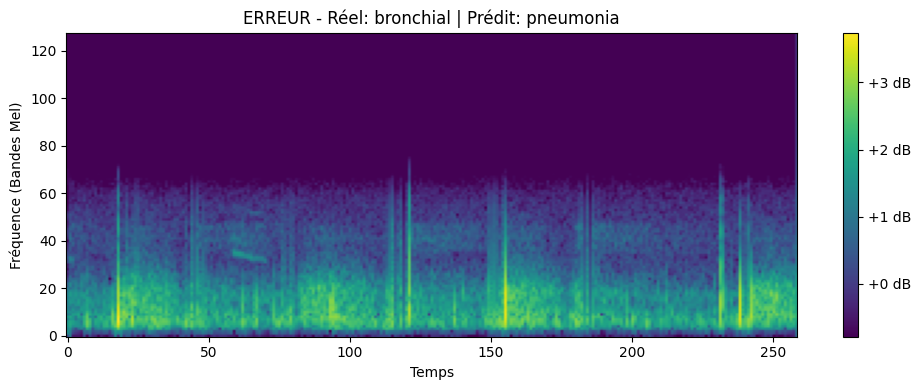

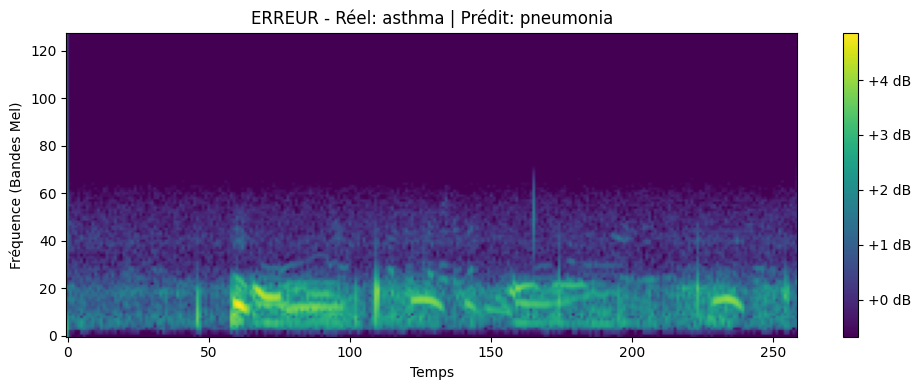

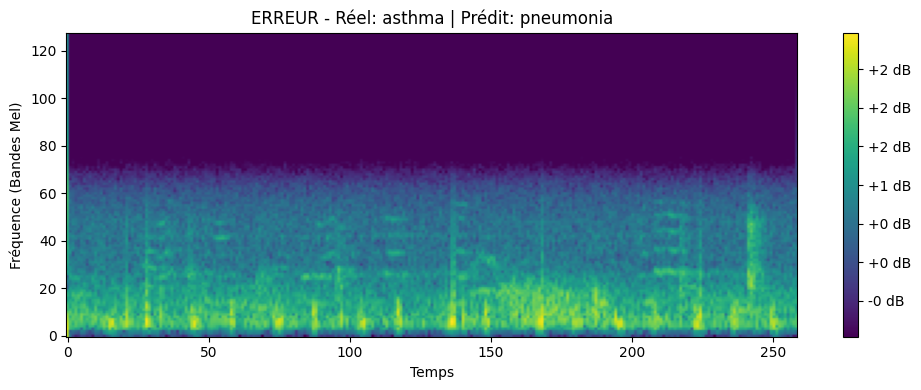

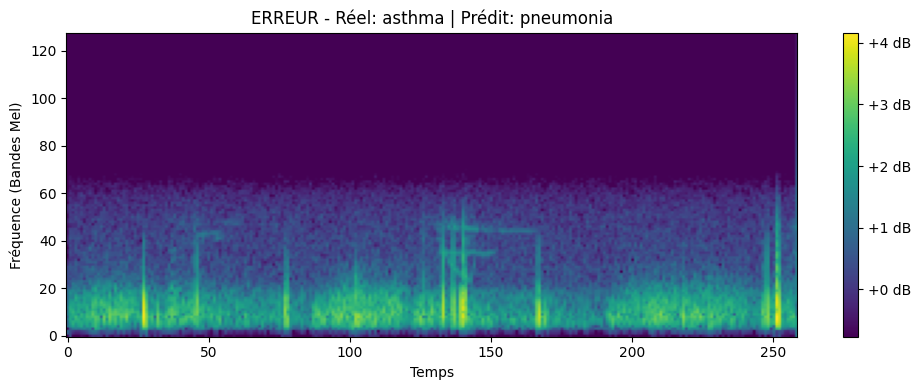

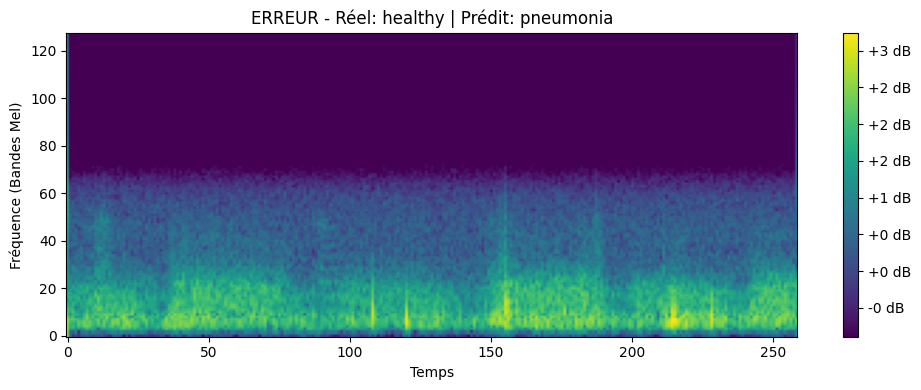

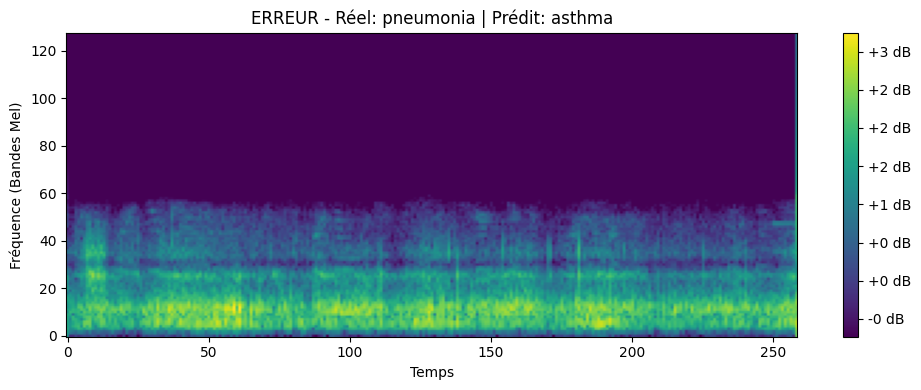

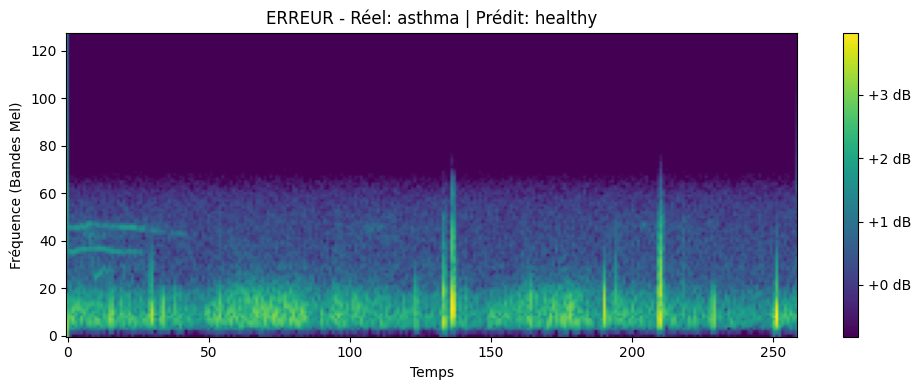

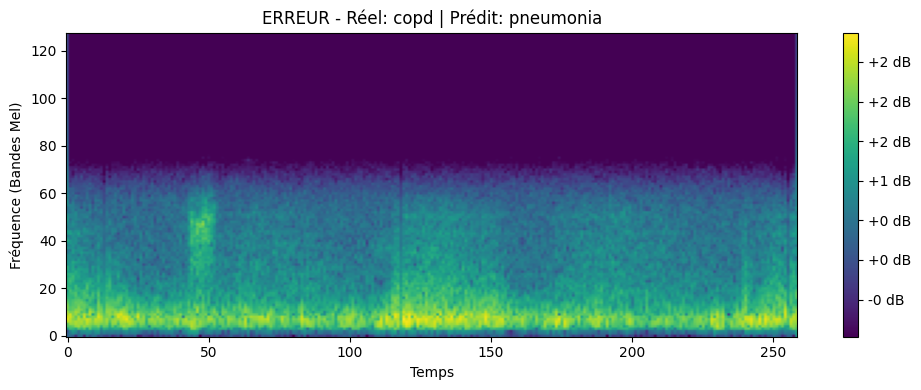

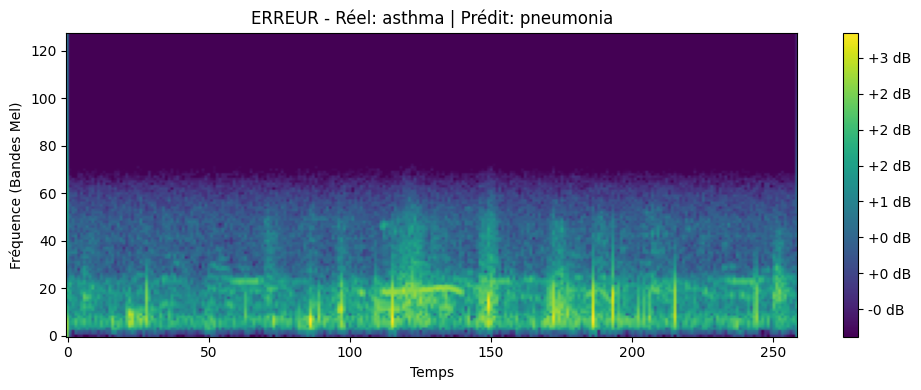

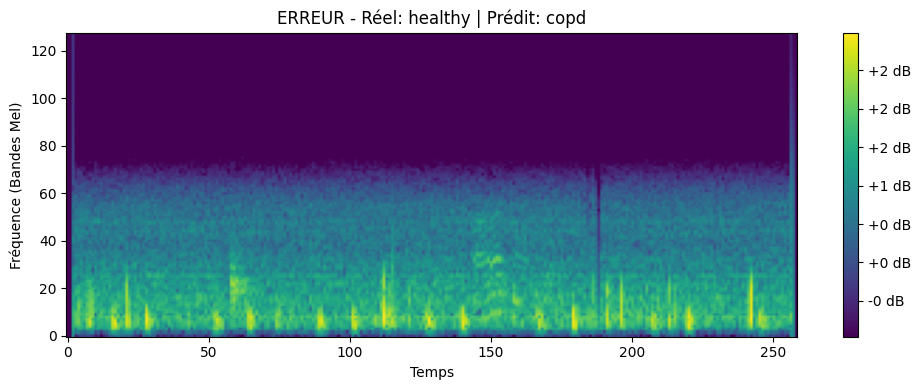

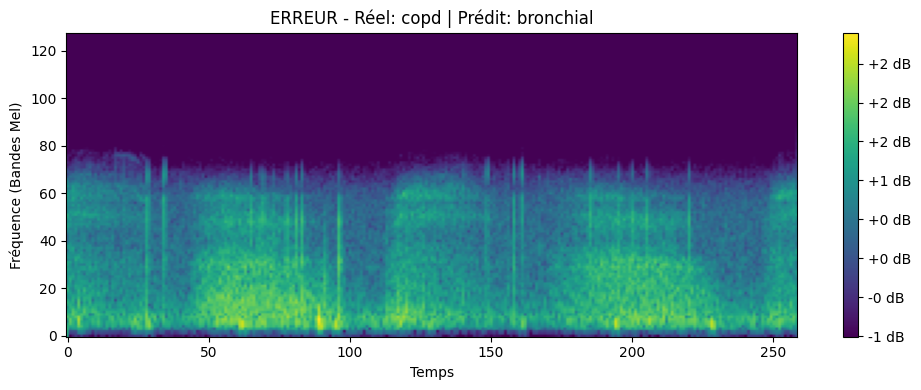

In [8]:
# Masque des erreurs (indices où la prédiction est différente de la réalité)
errors_indices = np.where(y_test != y_test_pred)[0]

print(f"Nombre total d'erreurs : {len(errors_indices)}")

augmenter.eval()

for idx in errors_indices[:]:
    plt.figure(figsize=(10, 4))
    
    raw_audio = torch.tensor(X_test[idx], dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            spec_tensor = augmenter(raw_audio, augment=False)
            
    spec_numpy = spec_tensor.squeeze().cpu().numpy()
    plt.imshow(spec_numpy, aspect='auto', origin='lower', cmap='viridis')
    
    real_class = le.classes_[y_test[idx]]
    pred_class = le.classes_[y_test_pred[idx]]
    
    plt.title(f"ERREUR - Réel: {real_class} | Prédit: {pred_class}")
    plt.colorbar(format='%+2.0f dB')
    plt.xlabel('Temps')
    plt.ylabel('Fréquence (Bandes Mel)')
    plt.tight_layout()
    plt.show()